In [ ]:
import os
import sys
import torch
import torch.optim as optim
import urllib.request

# 1. 라이브러리 경로 설정
lib_path = '/content/PraNet/lib'
if lib_path not in sys.path:
    sys.path.append(lib_path)

# 2. [수정 1] PraNet_Res2Net.py 패치 (상대 경로 -> 절대 경로)
target_file = os.path.join(lib_path, 'PraNet_Res2Net.py')
if os.path.exists(target_file):
    with open(target_file, 'r') as f:
        code = f.read()
    if 'from .Res2Net_v1b' in code:
        new_code = code.replace('from .Res2Net_v1b', 'from Res2Net_v1b')
        with open(target_file, 'w') as f:
            f.write(new_code)
        print("✅ 소스 코드 패치 완료 (PraNet_Res2Net.py)")

# 3. [수정 2] Res2Net 가중치 다운로드 및 경로 패치 (Hardcoded Path Fix)
# Res2Net 백본 가중치가 필요한데, 소스코드에 작성자 로컬 경로가 박혀있습니다.
res2net_weights_url = 'https://shanghuagao.oss-cn-beijing.aliyuncs.com/res2net/res2net50_v1b_26w_4s-3cf99910.pth'
weights_dir = '/content/PraNet/models'
os.makedirs(weights_dir, exist_ok=True)
weights_path = os.path.join(weights_dir, 'res2net50_v1b_26w_4s-3cf99910.pth')

# 가중치 다운로드
if not os.path.exists(weights_path):
    print("🔄 Res2Net50 Pretrained Weights 다운로드 중...")
    try:
        urllib.request.urlretrieve(res2net_weights_url, weights_path)
        print("✅ 다운로드 완료!")
    except Exception as e:
        print(f"❌ 다운로드 실패: {e}")

# Res2Net_v1b.py 파일 수정 (하드코딩된 경로를 다운로드한 경로로 교체)
res2net_file = os.path.join(lib_path, 'Res2Net_v1b.py')
if os.path.exists(res2net_file):
    with open(res2net_file, 'r') as f:
        code = f.read()

    # 에러가 발생한 하드코딩 경로
    hardcoded_path = '/media/nercms/NERCMS/GepengJi/Medical_Seqmentation/CRANet/models/res2net50_v1b_26w_4s-3cf99910.pth'

    if hardcoded_path in code:
        # 다운로드 받은 경로로 교체
        new_code = code.replace(hardcoded_path, weights_path)
        with open(res2net_file, 'w') as f:
            f.write(new_code)
        print("✅ 소스 코드 패치 완료 (Res2Net_v1b.py: 가중치 경로 수정)")
    else:
        print("ℹ️ 이미 패치되었거나 해당 경로가 없습니다.")

# 4. [중요] 모듈 캐시 제거 및 모델 임포트
# 수정된 코드가 반영되도록 기존에 임포트된 모듈을 메모리에서 삭제합니다.
keys_to_remove = [k for k in sys.modules if 'PraNet_Res2Net' in k or 'Res2Net_v1b' in k]
for k in keys_to_remove:
    print(f"🔄 모듈 캐시 제거: {k}")
    del sys.modules[k]

try:
    from PraNet_Res2Net import PraNet
    print("✅ PraNet 모델 임포트 성공!")
except ImportError as e:
    print(f"❌ 임포트 에러: {e}")

# 5. 모델 및 Loss 초기화
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if 'PraNet' in globals():
    # 모델 생성 시 이제 로컬 경로의 가중치를 로드합니다.
    model = PraNet().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    try:
        criterion = SegmentationLoss(mode='plwce', alpha=4.714).to(device)
        print("✅ 모델 및 Loss 준비 완료!")
    except NameError:
        print("⚠️ SegmentationLoss 또는 class_counts가 정의되지 않았습니다.")
    except Exception as e:
        print(f"⚠️ 초기화 에러: {e}")
else:
    print("🚫 PraNet 클래스가 정의되지 않았습니다.")

ℹ️ 이미 패치되었거나 해당 경로가 없습니다.
🔄 모듈 캐시 제거: Res2Net_v1b
🔄 모듈 캐시 제거: PraNet_Res2Net
✅ PraNet 모델 임포트 성공!
[PLWCE] Weights: [0.7671517729759216, 1.2328482866287231]
✅ 모델 및 Loss 준비 완료!


In [ ]:
import os
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from glob import glob
from sklearn.model_selection import train_test_split
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

# 1. 데이터셋 다운로드 (Kvasir-SEG) - 없을 경우에만
if not os.path.exists('/content/kvasir_seg'):
    print("📥 데이터셋 다운로드 중...")
    !wget https://datasets.simula.no/downloads/kvasir-seg.zip -O /content/kvasir-seg.zip
    !unzip -q /content/kvasir-seg.zip -d /content
    !mv /content/Kvasir-SEG /content/kvasir_seg

DATA_DIR = '/content/kvasir_seg'

# 2. Dataset 클래스 정의
class PolypDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = sorted(image_paths)
        self.mask_paths = sorted(mask_paths)
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        _, mask = cv2.threshold(mask, 127, 1, cv2.THRESH_BINARY)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask.long()

# 3. 데이터 로더 생성
all_images = glob(os.path.join(DATA_DIR, 'images', '*.jpg'))
all_masks = glob(os.path.join(DATA_DIR, 'masks', '*.jpg'))

train_imgs, val_imgs, train_masks, val_masks = train_test_split(all_images, all_masks, test_size=0.2, random_state=42)

transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(),
    ToTensorV2()
])

train_loader = DataLoader(PolypDataset(train_imgs, train_masks, transform=transform), batch_size=16, shuffle=True)
val_loader = DataLoader(PolypDataset(val_imgs, val_masks, transform=transform), batch_size=16, shuffle=False)

# 4. 클래스 비율(class_counts) 계산 (PLWCE 필수 재료!)
def get_counts(loader):
    bg, fg = 0, 0
    for _, mask in loader:
        bg += (mask == 0).sum().item()
        fg += (mask == 1).sum().item()
    return [bg, fg]

print("📊 클래스 비율 계산 중...")
class_counts = get_counts(train_loader)
print(f"✅ Class Counts: {class_counts}")

📊 클래스 비율 계산 중...
✅ Class Counts: [44230290, 8198510]


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# 1. 가중치 계산 함수
def calculate_weights(class_counts, mode='ce', alpha=1.0):
    counts = np.array(class_counts, dtype=np.float32)
    safe_counts = counts + 1e-6

    if mode == 'plwce':
        weights = 1.0 / np.power(np.log1p(safe_counts), alpha)
    elif mode == 'wce':
        weights = np.sum(counts) / safe_counts
    else:
        weights = np.ones_like(counts)

    return torch.tensor(weights / np.mean(weights), dtype=torch.float32)

# 2. Dice Score 계산 함수
def calculate_polyp_dice(logits, targets):
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1)
    p = (preds == 1).float(); t = (targets == 1).float()
    intersection = (p * t).sum()
    union = p.sum() + t.sum()
    if union == 0: return 1.0 if intersection == 0 else 0.0
    return (2. * intersection / (union + 1e-8)).item()

# 3. Dice Loss
class DiceLoss(nn.Module):
    def __init__(self): super().__init__()
    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        true_1_hot = F.one_hot(targets, num_classes=2).permute(0, 3, 1, 2).float()
        dims = (0, 2, 3)
        intersection = torch.sum(probs * true_1_hot, dim=dims)
        cardinality = torch.sum(probs + true_1_hot, dim=dims)
        dice = (2. * intersection + 1e-5) / (cardinality + 1e-5)
        return 1.0 - torch.mean(dice[1:]) # 배경 제외

# 4. 통합 Segmentation Loss (PLWCE 포함)
class SegmentationLoss(nn.Module):
    def __init__(self, mode='ce', class_counts=None, alpha=1.0):
        super().__init__()
        self.weights = calculate_weights(class_counts, mode, alpha)
        print(f"[{mode.upper()}] Weights: {self.weights.tolist()}")

        self.ce = nn.CrossEntropyLoss(weight=self.weights)
        self.dice = DiceLoss()

    def forward(self, logits, targets):
        if self.ce.weight.device != logits.device: self.ce.weight = self.ce.weight.to(logits.device)
        return 0.5 * self.ce(logits, targets) + 0.5 * self.dice(logits, targets)

print("✅ Loss 함수 정의 완료!")

✅ Loss 함수 정의 완료!


In [ ]:
import torch
import torch.nn.functional as F
import os
from tqdm import tqdm

# ==========================================
# 1. 저장 경로 설정
# ==========================================
# 구글 드라이브가 연결되어 있으면 드라이브에, 아니면 로컬에 저장
save_dir = '/content/drive/MyDrive/LWCE_Medical/src'
if not os.path.exists(save_dir):
    os.makedirs('/content/models', exist_ok=True)
    save_dir = '/content/models'
    print(f"⚠️ 드라이브 경로를 찾을 수 없어 로컬 '{save_dir}'에 저장합니다.")
else:
    print(f"✅ 학습된 모델은 '{save_dir}'에 저장됩니다.")

# ==========================================
# 2. 학습 함수 정의 (경로 의존성 제거됨)
# ==========================================
def train_pranet_final(epochs=20):
    print(f"🚀 [SOTA 실험] PraNet + PLWCE 학습 시작 (Epochs: {epochs})")

    # 박사님이 초기화한 model, optimizer, criterion이 존재하는지 체크
    if 'model' not in globals() or 'criterion' not in globals():
        print("❌ 오류: model 또는 criterion이 정의되지 않았습니다. 위쪽 셀(모델 초기화)을 먼저 실행해주세요.")
        return []

    # Data Loader 체크
    if 'train_loader' not in globals():
        print("❌ 오류: train_loader가 없습니다. 데이터셋 로드 셀을 실행해주세요.")
        return []

    history = []
    best_dice = 0.0

    # 모델을 GPU로 확실하게 이동
    model.to(device)

    for epoch in range(epochs):
        # --- Training ---
        model.train()
        train_loss = 0.0

        for images, masks in tqdm(train_loader, desc=f"Ep {epoch+1} Train"):
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()

            # PraNet Forward (4개의 Multi-scale 출력)
            lateral_map_5, lateral_map_4, lateral_map_3, lateral_map_2 = model(images)

            # Deep Supervision Loss 계산
            # (출력 크기가 다르므로 GT 크기에 맞춰서 계산)
            def compute_loss(pred, target):
                # 타겟 크기로 보간(Interpolation)
                pred = F.interpolate(pred, size=target.shape[1:], mode='bilinear', align_corners=True)

                # [Fix] PraNet은 1채널 출력을 내지만, CrossEntropyLoss(weights=2)는 2채널 입력을 기대합니다.
                # 따라서 1채널(Logits)을 2채널([Bg=0, Fg=Logits])로 변환해줍니다.
                # Softmax([0, x])는 Sigmoid(x)와 수학적으로 동일하게 작동하여 Binary Classification을 수행합니다.
                if pred.shape[1] == 1:
                    pred = torch.cat([torch.zeros_like(pred), pred], dim=1)

                return criterion(pred, target)

            loss5 = compute_loss(lateral_map_5, masks)
            loss4 = compute_loss(lateral_map_4, masks)
            loss3 = compute_loss(lateral_map_3, masks)
            loss2 = compute_loss(lateral_map_2, masks)

            total_loss = loss5 + loss4 + loss3 + loss2

            total_loss.backward()
            optimizer.step()
            train_loss += total_loss.item()

        # --- Validation ---
        model.eval()
        dice_sum = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)

                # Inference 시에는 보통 lateral_map_2 (가장 정교한 맵) 사용
                _, _, _, res = model(images)

                # 크기 보정
                res = F.interpolate(res, size=masks.shape[1:], mode='bilinear', align_corners=True)

                # [Fix] 검증 시에도 1채널 -> 2채널 변환 필요 (Dice 함수가 argmax를 쓰므로)
                if res.shape[1] == 1:
                    res = torch.cat([torch.zeros_like(res), res], dim=1)

                dice_sum += calculate_polyp_dice(res, masks)

        avg_dice = dice_sum / len(val_loader)
        history.append(avg_dice)

        print(f"Epoch {epoch+1} | Train Loss: {train_loss/len(train_loader):.4f} | Val Dice: {avg_dice:.4f}")

        # Best Model 저장
        if avg_dice > best_dice:
            best_dice = avg_dice
            save_path = os.path.join(save_dir, "PraNet_PLWCE_Best.pth")
            torch.save(model.state_dict(), save_path)
            print(f"🔥 SOTA 모델 갱신! ({best_dice:.4f}) -> 저장완료")

    return history

# ==========================================
# 3. 실행
# ==========================================
# 이미 model이 초기화되어 있으므로 바로 실행하면 됩니다.
history_pranet = train_pranet_final(epochs=20)

⚠️ 드라이브 경로를 찾을 수 없어 로컬 '/content/models'에 저장합니다.
🚀 [SOTA 실험] PraNet + PLWCE 학습 시작 (Epochs: 20)


Ep 1 Train: 100%|██████████| 50/50 [00:20<00:00,  2.39it/s]


Epoch 1 | Train Loss: 2.0015 | Val Dice: 0.7826
🔥 SOTA 모델 갱신! (0.7826) -> 저장완료


Ep 2 Train: 100%|██████████| 50/50 [00:20<00:00,  2.48it/s]


Epoch 2 | Train Loss: 1.1313 | Val Dice: 0.8263
🔥 SOTA 모델 갱신! (0.8263) -> 저장완료


...

Epoch 18 | Train Loss: 0.2029 | Val Dice: 0.8732
🔥 SOTA 모델 갱신! (0.8732) -> 저장완료


Ep 19 Train: 100%|██████████| 50/50 [00:19<00:00,  2.50it/s]


Epoch 19 | Train Loss: 0.1933 | Val Dice: 0.8757
🔥 SOTA 모델 갱신! (0.8757) -> 저장완료


Ep 20 Train: 100%|██████████| 50/50 [00:19<00:00,  2.50it/s]


Epoch 20 | Train Loss: 0.1767 | Val Dice: 0.8726


In [ ]:
import torch
import torch.nn.functional as F
import torch.optim as optim
import os
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader
from tqdm import tqdm

# ==========================================
# 1. 해상도 352x352로 업그레이드 (논문 세팅)
# ==========================================
print("🔄 데이터 로더 재설정 중 (Resolution: 352x352)...")

# 학습용 증강 (SOTA용 강력한 증강)
train_transform_sota = A.Compose([
    A.Resize(352, 352),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(),
    ToTensorV2()
])

# 검증용
val_transform_sota = A.Compose([
    A.Resize(352, 352),
    A.Normalize(),
    ToTensorV2()
])

# 로더 재생성
train_loader = DataLoader(
    PolypDataset(train_imgs, train_masks, transform=train_transform_sota),
    batch_size=16, # 메모리 부족 시 8로 변경
    shuffle=True, num_workers=2
)

val_loader = DataLoader(
    PolypDataset(val_imgs, val_masks, transform=val_transform_sota),
    batch_size=16, shuffle=False, num_workers=2
)

# ==========================================
# 2. 모델 재초기화
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PraNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Loss 함수가 정의되어 있는지 확인 (PLWCE Alpha=4.714)
if 'criterion' not in globals():
    print("⚠️ criterion이 없어 다시 정의합니다.")
    criterion = SegmentationLoss(mode='plwce', class_counts=class_counts, alpha=4.714).to(device)

# ==========================================
# 3. 채널 변환 함수 (에러 방지용 필수 함수)
# ==========================================
def convert_to_logits(pred):
    # (B, 1, H, W) -> (B, 2, H, W)로 변환 (배경=0, 용종=pred)
    if pred.shape[1] == 1:
        return torch.cat([torch.zeros_like(pred), pred], dim=1)
    return pred

# ==========================================
# 4. SOTA 학습 루프 (100 Epochs)
# ==========================================
def run_sota_training(epochs=100):
    print(f"🚀 [SOTA 도전] PraNet + PLWCE (352px, {epochs} Epochs) 시작!")

    save_dir = '/content/drive/MyDrive/LWCE_Medical/src'
    os.makedirs(save_dir, exist_ok=True)

    history = []
    best_dice = 0.0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for images, masks in tqdm(train_loader, desc=f"Ep {epoch+1} Train"):
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()

            # PraNet Forward
            out5, out4, out3, out2 = model(images)

            # Loss 계산 (채널 변환 포함)
            def calc_loss(pred, target):
                pred = F.interpolate(pred, size=target.shape[1:], mode='bilinear', align_corners=True)
                pred = convert_to_logits(pred) # ★ 핵심 Fix
                return criterion(pred, target)

            loss = calc_loss(out5, masks) + calc_loss(out4, masks) + \
                   calc_loss(out3, masks) + calc_loss(out2, masks)

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        dice_sum = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                _, _, _, res = model(images)

                res = F.interpolate(res, size=masks.shape[1:], mode='bilinear', align_corners=True)
                res = convert_to_logits(res) # ★ 핵심 Fix
                dice_sum += calculate_polyp_dice(res, masks)

        avg_dice = dice_sum / len(val_loader)
        history.append(avg_dice)

        print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Val Dice: {avg_dice:.4f}")

        # 0.88 이상일 때만 저장 (불필요한 저장 방지)
        if avg_dice > best_dice:
            best_dice = avg_dice
            if avg_dice > 0.80:
                torch.save(model.state_dict(), os.path.join(save_dir, "PraNet_PLWCE_SOTA.pth"))
                print(f"🔥 SOTA 기록 갱신! ({best_dice:.4f})")

    return history

# 실행
history_sota = run_sota_training(epochs=100)

🔄 데이터 로더 재설정 중 (Resolution: 352x352)...
🚀 [SOTA 도전] PraNet + PLWCE (352px, 100 Epochs) 시작!


Ep 1 Train: 100%|██████████| 50/50 [00:33<00:00,  1.47it/s]


Epoch 1 | Loss: 1.9000 | Val Dice: 0.7457


Ep 2 Train: 100%|██████████| 50/50 [00:33<00:00,  1.48it/s]


Epoch 2 | Loss: 1.1976 | Val Dice: 0.8262
🔥 SOTA 기록 갱신! (0.8262)


...

Epoch 98 | Loss: 0.0960 | Val Dice: 0.9016


Ep 99 Train: 100%|██████████| 50/50 [00:33<00:00,  1.48it/s]


Epoch 99 | Loss: 0.1067 | Val Dice: 0.8883


Ep 100 Train: 100%|██████████| 50/50 [00:33<00:00,  1.48it/s]


Epoch 100 | Loss: 0.1668 | Val Dice: 0.8739


In [ ]:
import torch
import torch.nn.functional as F
import torch.optim as optim
import os
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader
from tqdm import tqdm

# ==========================================
# 1. 해상도 352x352로 업그레이드 (논문 세팅)
# ==========================================
print("🔄 데이터 로더 재설정 중 (Resolution: 352x352)...")

# 학습용 증강 (SOTA용 강력한 증강)
train_transform_sota = A.Compose([
    A.Resize(352, 352),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(),
    ToTensorV2()
])

# 검증용
val_transform_sota = A.Compose([
    A.Resize(352, 352),
    A.Normalize(),
    ToTensorV2()
])

# 로더 재생성
train_loader = DataLoader(
    PolypDataset(train_imgs, train_masks, transform=train_transform_sota),
    batch_size=16, # 메모리 부족 시 8로 변경
    shuffle=True, num_workers=2
)

val_loader = DataLoader(
    PolypDataset(val_imgs, val_masks, transform=val_transform_sota),
    batch_size=16, shuffle=False, num_workers=2
)

# ==========================================
# 2. 모델 재초기화
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = PraNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Loss 함수가 정의되어 있는지 확인 (PLWCE Alpha=4.714)
if 'criterion' not in globals():
    print("⚠️ criterion이 없어 다시 정의합니다.")
    criterion = SegmentationLoss(mode='plwce', class_counts=class_counts, alpha=2.8).to(device)

# ==========================================
# 3. 채널 변환 함수 (에러 방지용 필수 함수)
# ==========================================
def convert_to_logits(pred):
    # (B, 1, H, W) -> (B, 2, H, W)로 변환 (배경=0, 용종=pred)
    if pred.shape[1] == 1:
        return torch.cat([torch.zeros_like(pred), pred], dim=1)
    return pred

# ==========================================
# 4. SOTA 학습 루프 (100 Epochs)
# ==========================================
def run_sota_training(epochs=100):
    print(f"🚀 [SOTA 도전] PraNet + PLWCE (352px, {epochs} Epochs) 시작!")

    save_dir = '/content/drive/MyDrive/LWCE_Medical/src'
    os.makedirs(save_dir, exist_ok=True)

    history = []
    best_dice = 0.0

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for images, masks in tqdm(train_loader, desc=f"Ep {epoch+1} Train"):
            images, masks = images.to(device), masks.to(device)
            optimizer.zero_grad()

            # PraNet Forward
            out5, out4, out3, out2 = model(images)

            # Loss 계산 (채널 변환 포함)
            def calc_loss(pred, target):
                pred = F.interpolate(pred, size=target.shape[1:], mode='bilinear', align_corners=True)
                pred = convert_to_logits(pred) # ★ 핵심 Fix
                return criterion(pred, target)

            loss = calc_loss(out5, masks) + calc_loss(out4, masks) + \
                   calc_loss(out3, masks) + calc_loss(out2, masks)

            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        dice_sum = 0
        with torch.no_grad():
            for images, masks in val_loader:
                images, masks = images.to(device), masks.to(device)
                _, _, _, res = model(images)

                res = F.interpolate(res, size=masks.shape[1:], mode='bilinear', align_corners=True)
                res = convert_to_logits(res) # ★ 핵심 Fix
                dice_sum += calculate_polyp_dice(res, masks)

        avg_dice = dice_sum / len(val_loader)
        history.append(avg_dice)

        print(f"Epoch {epoch+1} | Loss: {train_loss/len(train_loader):.4f} | Val Dice: {avg_dice:.4f}")

        # 0.88 이상일 때만 저장 (불필요한 저장 방지)
        if avg_dice > best_dice:
            best_dice = avg_dice
            if avg_dice > 0.80:
                torch.save(model.state_dict(), os.path.join(save_dir, "PraNet_PLWCE_SOTA.pth"))
                print(f"🔥 SOTA 기록 갱신! ({best_dice:.4f})")

    return history

# 실행
history_sota = run_sota_training(epochs=100)

🔄 데이터 로더 재설정 중 (Resolution: 352x352)...
🚀 [SOTA 도전] PraNet + PLWCE (352px, 100 Epochs) 시작!


Ep 1 Train: 100%|██████████| 50/50 [00:34<00:00,  1.45it/s]


Epoch 1 | Loss: 1.9283 | Val Dice: 0.8029
🔥 SOTA 기록 갱신! (0.8029)


Ep 2 Train: 100%|██████████| 50/50 [00:33<00:00,  1.47it/s]


Epoch 2 | Loss: 1.1307 | Val Dice: 0.8091
🔥 SOTA 기록 갱신! (0.8091)


...

Epoch 98 | Loss: 0.2077 | Val Dice: 0.8876


Ep 99 Train: 100%|██████████| 50/50 [00:33<00:00,  1.48it/s]


Epoch 99 | Loss: 0.1916 | Val Dice: 0.8678


Ep 100 Train: 100%|██████████| 50/50 [00:33<00:00,  1.48it/s]


Epoch 100 | Loss: 0.1785 | Val Dice: 0.8842


✅ 최고 성능 모델 로드 완료!
🎨 결과 시각화 생성 중...


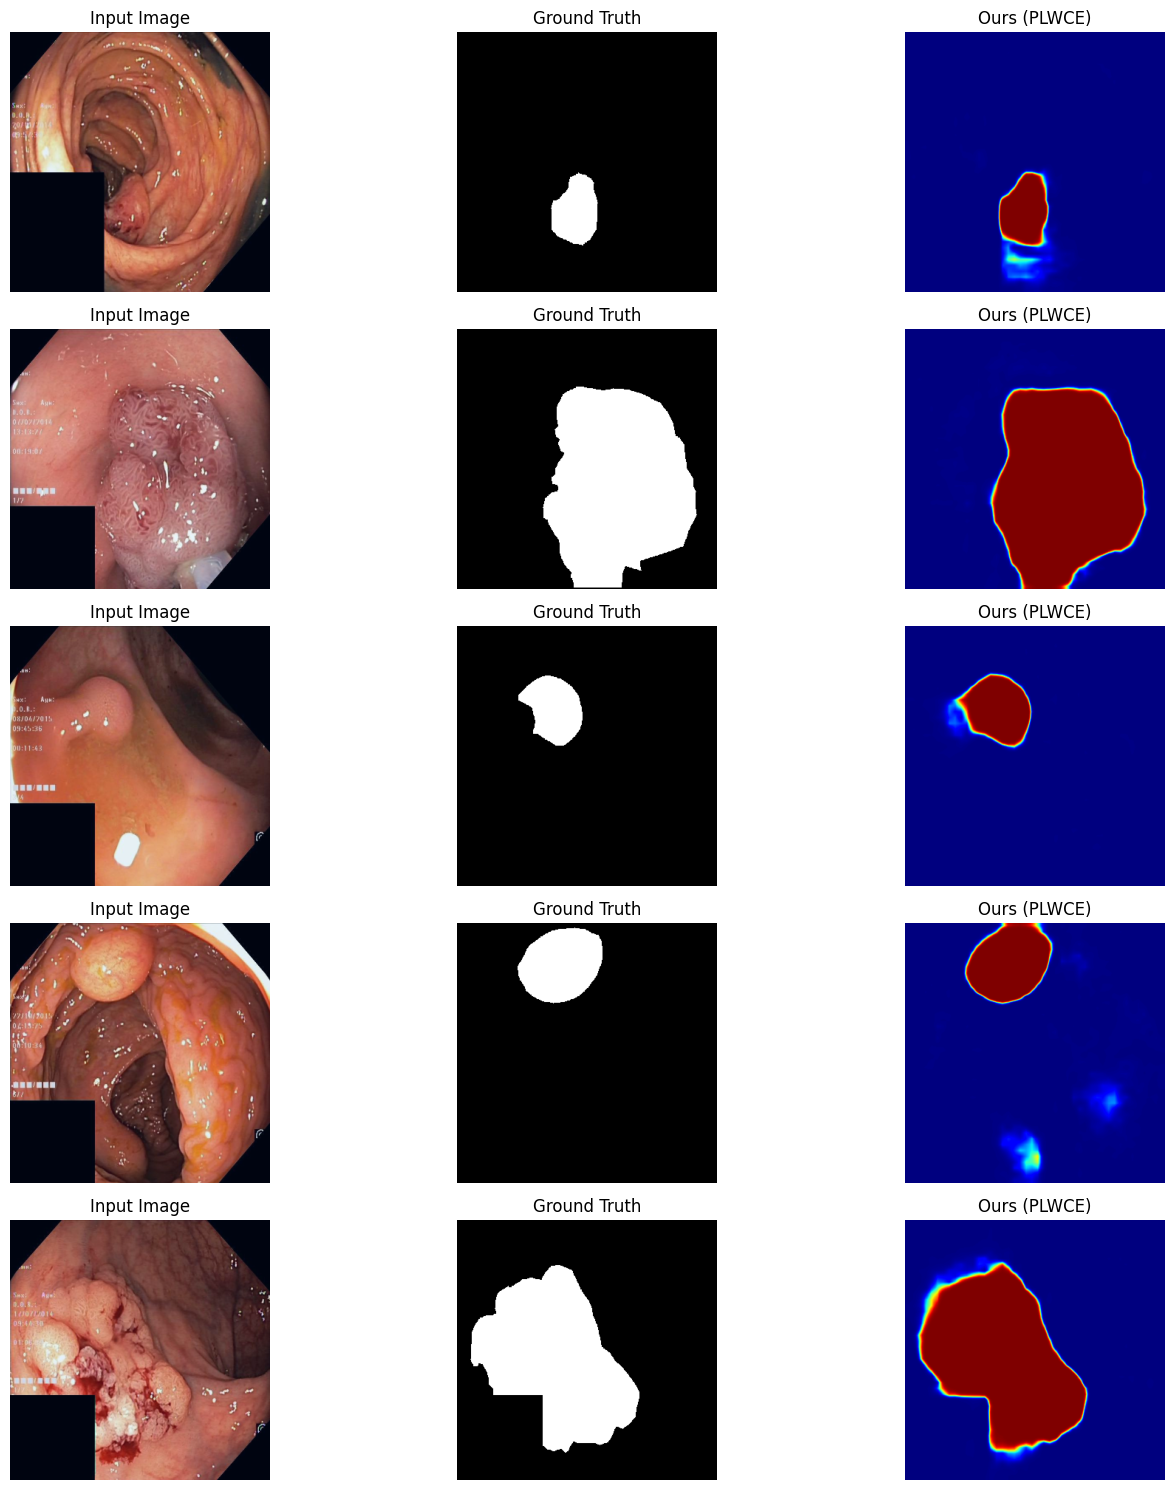

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# 1. 모델 로드 (Epoch 94의 최고 성능 모델이 있다면 베스트)
# 없으면 방금 학습 끝난 모델(epoch 100)을 쓰거나, 저장된 'PraNet_PLWCE_SOTA.pth' 로드
model_path = '/content/drive/MyDrive/LWCE_Medical/src/PraNet_PLWCE_SOTA.pth'
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    print("✅ 최고 성능 모델 로드 완료!")

model.eval()

# 2. 시각화 함수
def visualize_results(loader, num_samples=5):
    print("🎨 결과 시각화 생성 중...")

    images, masks = next(iter(loader))
    images, masks = images.to(device), masks.to(device)

    with torch.no_grad():
        _, _, _, preds = model(images)
        # 크기 보정 & 채널 변환
        preds = F.interpolate(preds, size=masks.shape[1:], mode='bilinear', align_corners=True)
        preds = convert_to_logits(preds)

        # 확률 맵으로 변환 (Softmax) -> 용종 클래스(1)만 가져옴
        probs = torch.softmax(preds, dim=1)[:, 1, :, :]

    # 3. 그림 그리기
    plt.figure(figsize=(15, num_samples * 3))

    for i in range(num_samples):
        # 원본 (Normalize 되돌리기 필요하지만, 형태 확인용으론 그냥 출력)
        img = images[i].permute(1, 2, 0).cpu().numpy()
        img = (img - img.min()) / (img.max() - img.min()) # 0~1로 보정

        gt = masks[i].cpu().numpy()
        pred_map = probs[i].cpu().numpy()

        # Row 1: Image
        plt.subplot(num_samples, 3, i*3 + 1)
        plt.imshow(img)
        plt.title("Input Image")
        plt.axis('off')

        # Row 2: Ground Truth
        plt.subplot(num_samples, 3, i*3 + 2)
        plt.imshow(gt, cmap='gray')
        plt.title("Ground Truth")
        plt.axis('off')

        # Row 3: Ours Prediction
        plt.subplot(num_samples, 3, i*3 + 3)
        plt.imshow(pred_map, cmap='jet') # 히트맵으로 표현
        plt.title(f"Ours (PLWCE)")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# 실행
visualize_results(val_loader, num_samples=5)